**Clip:** ActionVFX practice footage — *"Mechanic in Electrical Explosion"*
(https://www.actionvfx.com/practice-footage/mechanic-in-electrical-explosion)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
import cv2
import time
import imageio.v2 as imageio

np.set_printoptions(suppress=True, precision=3)
plt.rcParams['figure.figsize'] = (10, 6)

In [29]:
# ---- EDIT THESE PATHS ----
FRAMES_DIR = Path("frames")          # directory containing your 48 extracted frames
                                      # (e.g. frame_000.png ... frame_047.png)
BG_PLATE_PATH = Path("output.png") # background plate, width >= 2.5 * frame width
FRAME_GLOB = "*.png"                 # adjust to your extension (*.png / *.jpg)

def load_frames(frames_dir, pattern=FRAME_GLOB):
    paths = sorted(Path(frames_dir).glob(pattern))
    assert len(paths) > 0, f"No frames found in {frames_dir} matching {pattern}"
    frames = [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) for p in paths]
    return frames, paths

frames, frame_paths = load_frames(FRAMES_DIR)
bg_plate = cv2.cvtColor(cv2.imread(str(BG_PLATE_PATH)), cv2.COLOR_BGR2RGB)
print(f"Loaded {len(frames)} frames of shape {frames[0].shape}")
print(f"Background plate shape {bg_plate.shape}")
assert bg_plate.shape[1] >= 2.5 * frames[0].shape[1], "background plate not wide enough to pan"

Loaded 60 frames of shape (1080, 2048, 3)
Background plate shape (1080, 5120, 3)


In [30]:
def to_ycbcr(rgb):
    '''BT.601 (studio-range) RGB -> YCbCr. rgb: uint8/float array, ..., 3, range [0,255].'''
    rgb = rgb.astype(np.float64) / 255.0
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    Y  = 16.0  + (65.481 * R + 128.553 * G + 24.966 * B)
    Cb = 128.0 + (-37.797 * R - 74.203 * G + 112.0 * B)
    Cr = 128.0 + (112.0 * R - 93.786 * G - 18.214 * B)
    out = np.stack([Y, Cb, Cr], axis=-1)
    return np.clip(out, 0, 255)

In [31]:
def key_naive_rgb(rgb, thresh=60):
    '''Hard key by green dominance in raw RGB: backing where G - max(R,B) > thresh.'''
    rgb = rgb.astype(np.float64)
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    dominance = G - np.maximum(R, B)
    is_backing = dominance > thresh
    return np.where(is_backing, 0.0, 1.0)  # alpha: 0 = backing, 1 = foreground


def key_chroma_hard(rgb, key_cbcr, thresh=25):
    '''Hard key on chroma distance alone in YCbCr (for comparison against RGB dominance).'''
    ycbcr = to_ycbcr(rgb)
    d = np.hypot(ycbcr[..., 1] - key_cbcr[0], ycbcr[..., 2] - key_cbcr[1])
    return np.where(d < thresh, 0.0, 1.0)

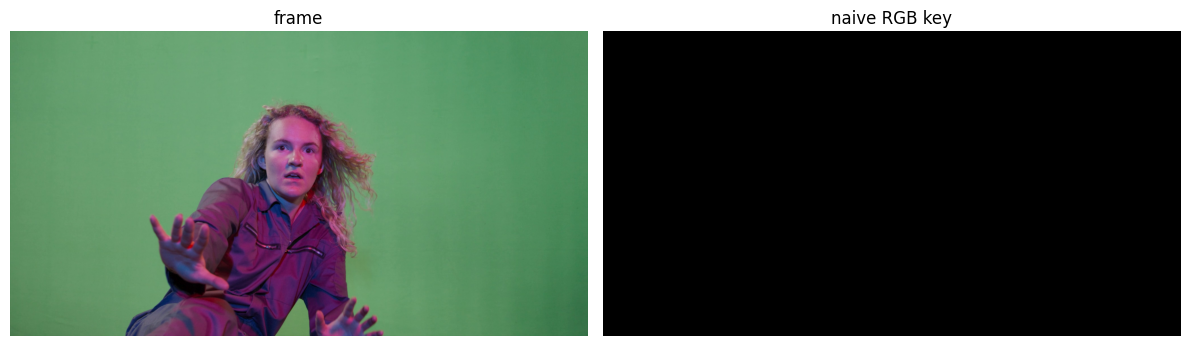

In [32]:
frame = frames[10]  # pick a representative frame — adjust index
alpha_naive = key_naive_rgb(frame, thresh=60)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(frame); ax[0].set_title("frame"); ax[0].axis('off')
ax[1].imshow(alpha_naive, cmap='gray'); ax[1].set_title("naive RGB key"); ax[1].axis('off')
plt.tight_layout(); plt.show()

In [33]:
# Helper to inspect a candidate failure pixel: click-free version — print RGB and
# green-dominance value at coordinates you choose after visually spotting a shadowed
# backing region that the naive key misses (shows up as foreground/white where it
# should be backing/black).
def inspect_pixel(rgb, y, x):
    R, G, B = rgb[y, x].astype(float)
    print(f"pixel ({y},{x})  R={R:.0f} G={G:.0f} B={B:.0f}  "
          f"G - max(R,B) = {G - max(R, B):.1f}")

# Example — replace y, x with coordinates you identify from the mask above:
# inspect_pixel(frame, y=..., x=...)

In [34]:
def estimate_key_colour(rgb, border=24):
    '''Estimate backing chroma (Cb, Cr) from a border strip of the frame.
    Uses the median, which is robust to a few foreground pixels leaking into the border.'''
    h, w = rgb.shape[:2]
    top, bottom = rgb[:border, :, :], rgb[-border:, :, :]
    left, right = rgb[:, :border, :], rgb[:, -border:, :]
    border_px = np.concatenate([
        top.reshape(-1, 3), bottom.reshape(-1, 3),
        left.reshape(-1, 3), right.reshape(-1, 3)
    ], axis=0)
    ycbcr = to_ycbcr(border_px[None, :, :])[0]
    return np.array([np.median(ycbcr[:, 1]), np.median(ycbcr[:, 2])])


def chroma_distance(rgb, key_cbcr):
    ycbcr = to_ycbcr(rgb)
    return np.hypot(ycbcr[..., 1] - key_cbcr[0], ycbcr[..., 2] - key_cbcr[1])

In [35]:
key_cbcr = estimate_key_colour(frame, border=24)
print("Estimated key (Cb, Cr):", key_cbcr)

Estimated key (Cb, Cr): [115.965 105.443]


In [36]:
from scipy.ndimage import binary_erosion

def population_masks(alpha_naive, erode_px=12, min_pixels=200):
    """Erode the naive backing/foreground masks inward so we sample only
    'confident' interior pixels, not the ambiguous boundary. Backs off
    erode_px automatically if a population would otherwise end up empty."""
    backing_mask = (alpha_naive < 0.5)
    fg_mask = ~backing_mask
    struct = np.ones((3, 3), dtype=bool)

    px = erode_px
    while px > 0:
        confident_backing = binary_erosion(backing_mask, structure=struct, iterations=px)
        confident_fg = binary_erosion(fg_mask, structure=struct, iterations=px)
        if confident_backing.sum() >= min_pixels and confident_fg.sum() >= min_pixels:
            break
        px -= 1
    else:
        raise RuntimeError(
            "Even erode_px=1 leaves an empty population -- the naive mask itself "
            "doesn't have a large enough solid backing or foreground region here. "
            "Pick a different frame, or sample masks by hand (a rectangle you draw) "
            "instead of eroding the naive mask."
        )

    if px < erode_px:
        print(f"Note: reduced erode_px from {erode_px} to {px} to keep both "
              f"populations non-empty.")

    boundary = ~confident_backing & ~confident_fg
    print(f"confident_backing={confident_backing.sum()}px  "
          f"confident_fg={confident_fg.sum()}px  boundary={boundary.sum()}px")
    return confident_backing, confident_fg, boundary


# The threshold=60 naive mask contains no sufficiently large backing region
# for this frame. Use the border as a reliable backing sample and select
# foreground samples from pixels farthest from the estimated key colour.

h, w = frame.shape[:2]
border_px = max(8, min(h, w) // 20)

border_mask = np.zeros((h, w), dtype=bool)
border_mask[:border_px, :] = True
border_mask[-border_px:, :] = True
border_mask[:, :border_px] = True
border_mask[:, -border_px:] = True

# Erode the border sample to avoid image-boundary contamination.
conf_back = binary_erosion(
    border_mask,
    structure=np.ones((3, 3), dtype=bool),
    iterations=2
)

d = chroma_distance(frame, key_cbcr)

# Prefer naive foreground pixels; otherwise use pixels farthest from the key.
candidate_fg = (alpha_naive >= 0.5) & ~conf_back
if candidate_fg.sum() < 200:
    candidate_fg = ~conf_back

fg_values = d[candidate_fg]
fg_cutoff = np.percentile(fg_values, 75)
conf_fg = candidate_fg & (d >= fg_cutoff)

# Guarantee enough foreground samples for the histogram.
if conf_fg.sum() < 200:
    flat_idx = np.flatnonzero(candidate_fg)
    keep = flat_idx[np.argsort(d.flat[flat_idx])[-min(200, len(flat_idx)):]]
    conf_fg = np.zeros((h, w), dtype=bool)
    conf_fg.flat[keep] = True

boundary = ~(conf_back | conf_fg)

print(f"confident_backing={conf_back.sum()}px  "
      f"confident_fg={conf_fg.sum()}px  boundary={boundary.sum()}px")
d = chroma_distance(frame, key_cbcr)

d_back  = d[conf_back]
d_fg    = d[conf_fg]
d_bound = d[boundary]

for name, arr in [("backing", d_back), ("boundary", d_bound), ("foreground", d_fg)]:
    if arr.size == 0:
        print(f"{name}: EMPTY -- skipping stats, see population_masks warning above")
        continue
    print(f"{name:10s} distance: mean={arr.mean():.2f}  "
          f"p5={np.percentile(arr,5):.2f}  p95={np.percentile(arr,95):.2f}  n={arr.size}")

confident_backing=302000px  confident_fg=477592px  boundary=1432248px
backing    distance: mean=7.91  p5=1.03  p95=47.88  n=302000
boundary   distance: mean=1.82  p5=0.14  p95=3.67  n=1432248
foreground distance: mean=41.71  p5=5.35  p95=64.76  n=477592


## 5. 5.2(b) — Soft matte and composite

In [37]:
def key_soft(rgb, key_cbcr=None, t_in=None, t_out=None):
    '''Fractional alpha from chroma distance: 0 at/below t_in (pure backing),
    1 at/above t_out (pure foreground), linear ramp between.'''
    if key_cbcr is None:
        key_cbcr = estimate_key_colour(rgb)
    d = chroma_distance(rgb, key_cbcr)
    alpha = (d - t_in) / max(t_out - t_in, 1e-6)
    return np.clip(alpha, 0.0, 1.0)


def composite(fg, bg, alpha, spill=True, strength=1.0):
    '''I = alpha*F + (1-alpha)*B, with optional spill suppression on F before blending.'''
    fg_use = suppress_spill(fg, alpha, strength=strength) if spill else fg
    fg_use = fg_use.astype(np.float64)
    bg = bg.astype(np.float64)
    a = alpha[..., None]
    out = a * fg_use + (1.0 - a) * bg
    return np.clip(out, 0, 255).astype(np.uint8)

t_in=21.61  t_out=41.61
fraction of pixels with fractional alpha: 0.0760


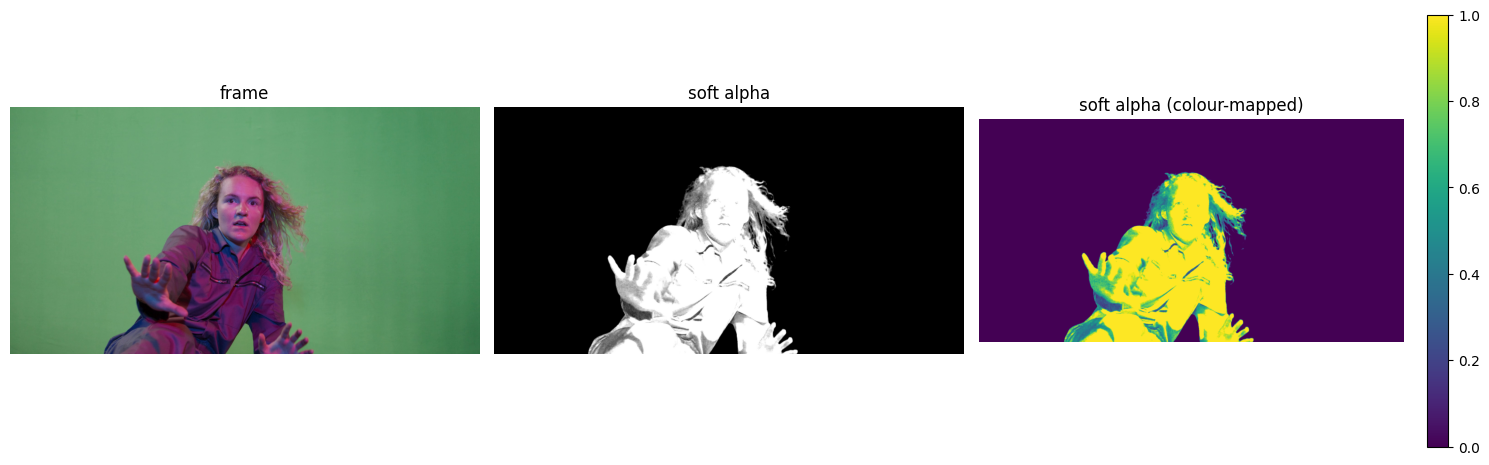

In [38]:
# Choose t_in / t_out from the distributions above. These defaults are data-driven —
# t_in just above the backing population's tail, t_out just below the foreground
# population's tail — but look at your histogram and override if it disagrees.
t_in = float(np.percentile(d_back, 95))
t_out = float(np.percentile(d_fg, 5))
if t_out <= t_in:
    # populations overlap — fall back to a fixed margin around the midpoint, and
    # flag it (see 5.2a analysis above)
    mid = 0.5 * (t_in + t_out)
    t_in, t_out = mid - 5, mid + 15
print(f"t_in={t_in:.2f}  t_out={t_out:.2f}")

alpha_soft = key_soft(frame, key_cbcr=key_cbcr, t_in=t_in, t_out=t_out)

frac_fractional = np.mean((alpha_soft > 0.02) & (alpha_soft < 0.98))
print(f"fraction of pixels with fractional alpha: {frac_fractional:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(frame); ax[0].set_title("frame"); ax[0].axis('off')
ax[1].imshow(alpha_soft, cmap='gray'); ax[1].set_title("soft alpha"); ax[1].axis('off')
im = ax[2].imshow(alpha_soft, cmap='viridis')
ax[2].set_title("soft alpha (colour-mapped)"); ax[2].axis('off')
plt.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

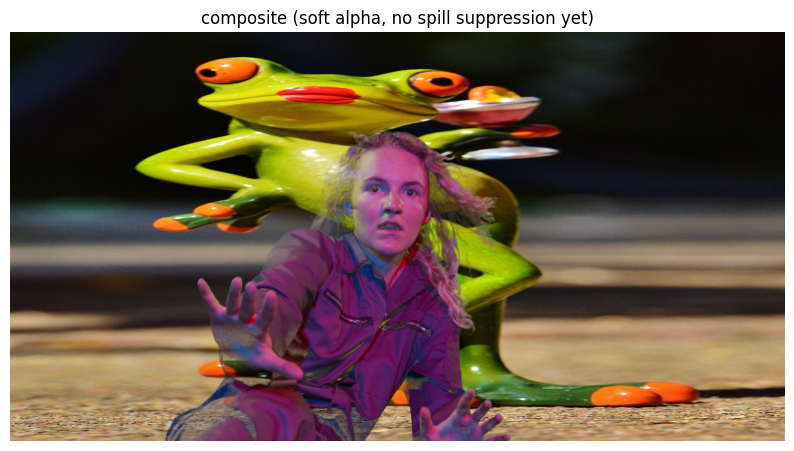

In [39]:
comp_no_bg_change = composite(frame, cv2.resize(bg_plate[:, :frame.shape[1]], (frame.shape[1], frame.shape[0])),
                               alpha_soft, spill=False)
plt.imshow(comp_no_bg_change); plt.axis('off'); plt.title("composite (soft alpha, no spill suppression yet)")
plt.show()

## 6. 5.2(c) — Spill suppression

In [40]:
def suppress_spill(rgb, alpha, strength=1.0):
    '''Desaturate green bounce toward the R/B average, scaled by (1 - alpha):
    pure-foreground pixels (alpha=1) are untouched; pixels near/behind the key
    (alpha->0) get fully corrected. This scaling matters because spill is a property
    of the *backing's* reflected light bouncing onto the subject near the edge —
    it should vanish exactly where the pixel is confidently foreground, and it should
    not touch background-replacement pixels at all (they're about to be replaced by
    the alpha blend anyway; scaling by (1-alpha) also makes the correction spatially
    smooth across the soft edge instead of introducing a hard seam).'''
    rgb = rgb.astype(np.float64)
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    avg_rb = 0.5 * (R + B)
    excess = np.maximum(G - avg_rb, 0.0)
    correction = strength * (1.0 - alpha) * excess
    G_new = G - correction
    out = np.stack([R, G_new, B], axis=-1)
    return np.clip(out, 0, 255).astype(np.uint8)

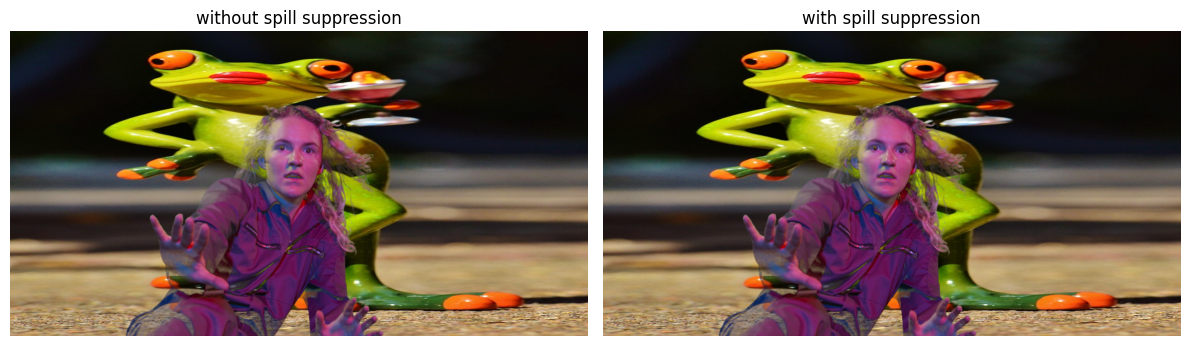

In [41]:
comp_with_spill = composite(frame, cv2.resize(bg_plate[:, :frame.shape[1]], (frame.shape[1], frame.shape[0])),
                             alpha_soft, spill=True, strength=1.0)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(comp_no_bg_change); ax[0].set_title("without spill suppression"); ax[0].axis('off')
ax[1].imshow(comp_with_spill); ax[1].set_title("with spill suppression"); ax[1].axis('off')
plt.tight_layout(); plt.show()

In [42]:
def green_excess(rgb, mask):
    rgb = rgb.astype(np.float64)
    R, G, B = rgb[..., 0][mask], rgb[..., 1][mask], rgb[..., 2][mask]
    return float(np.mean(np.maximum(G - 0.5 * (R + B), 0.0)))

fractional_mask = (alpha_soft > 0.02) & (alpha_soft < 0.98)
before = green_excess(frame, fractional_mask)
fg_corrected = suppress_spill(frame, alpha_soft, strength=1.0)
after = green_excess(fg_corrected, fractional_mask)
print(f"mean residual green excess over fractional-alpha pixels — before: {before:.2f}  after: {after:.2f}")

mean residual green excess over fractional-alpha pixels — before: 0.60  after: 0.07


mean |alpha_naive - alpha_soft| = 0.8238
gradient-field disagreement (grad_error) = 9.2652


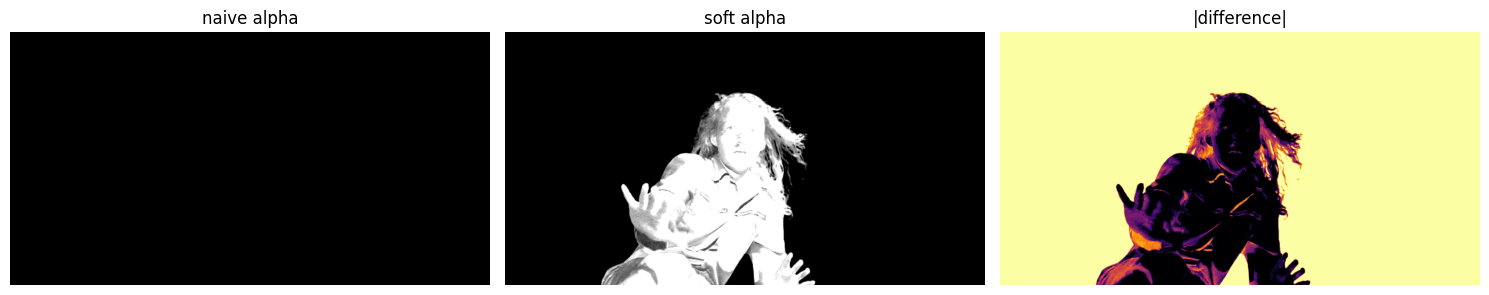

In [43]:
def sad(a, b):
    return float(np.abs(a.astype(np.float64) - b.astype(np.float64)).sum() / 1000.0)

def mse_alpha(a, b):
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64))**2))

def grad_error(a, b):
    from scipy.ndimage import gaussian_filter
    ga = np.hypot(*np.gradient(gaussian_filter(a.astype(np.float64), 1.0)))
    gb = np.hypot(*np.gradient(gaussian_filter(b.astype(np.float64), 1.0)))
    return float(np.abs(ga - gb).sum() / 1000.0)

mean_abs_diff = float(np.mean(np.abs(alpha_naive.astype(np.float64) - alpha_soft.astype(np.float64))))
grad_diff = grad_error(alpha_naive, alpha_soft)
print(f"mean |alpha_naive - alpha_soft| = {mean_abs_diff:.4f}")
print(f"gradient-field disagreement (grad_error) = {grad_diff:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(alpha_naive, cmap='gray'); ax[0].set_title("naive alpha"); ax[0].axis('off')
ax[1].imshow(alpha_soft, cmap='gray'); ax[1].set_title("soft alpha"); ax[1].axis('off')
ax[2].imshow(np.abs(alpha_naive - alpha_soft), cmap='inferno'); ax[2].set_title("|difference|"); ax[2].axis('off')
plt.tight_layout(); plt.show()

In [44]:
class ChromaLUT:
    '''Precomputes alpha for every (Cb, Cr) bin once; per-pixel keying then becomes a
    single table lookup instead of a distance calculation per pixel.'''

    def __init__(self, key_cbcr, t_in=None, t_out=None, bins=128):
        self.key_cbcr = np.asarray(key_cbcr, dtype=np.float64)
        self.t_in, self.t_out, self.bins = t_in, t_out, bins
        cb_vals = np.linspace(0, 255, bins)
        cr_vals = np.linspace(0, 255, bins)
        CB, CR = np.meshgrid(cb_vals, cr_vals, indexing='ij')
        d = np.hypot(CB - self.key_cbcr[0], CR - self.key_cbcr[1])
        a = (d - t_in) / max(t_out - t_in, 1e-6)
        self.table = np.clip(a, 0.0, 1.0).astype(np.float32)
        self.scale = (bins - 1) / 255.0

    def alpha(self, rgb):
        ycbcr = to_ycbcr(rgb)
        cb_idx = np.clip((ycbcr[..., 1] * self.scale).round().astype(np.int32), 0, self.bins - 1)
        cr_idx = np.clip((ycbcr[..., 2] * self.scale).round().astype(np.int32), 0, self.bins - 1)
        return self.table[cb_idx, cr_idx]

lut = ChromaLUT(key_cbcr, t_in=t_in, t_out=t_out, bins=128)
alpha_lut = lut.alpha(frame)
print("max |soft - LUT| on this frame:", np.abs(alpha_soft - alpha_lut).max())

max |soft - LUT| on this frame: 0.06691761119111644


In [45]:
def panning_crop(bg_plate, frame_shape, frame_idx, n_frames):
    fh, fw = frame_shape[:2]
    bh, bw = bg_plate.shape[:2]
    scale = fh / bh
    bg_resized = cv2.resize(bg_plate, (int(bw * scale), fh))
    bw2 = bg_resized.shape[1]
    max_offset = bw2 - fw
    assert max_offset > 0, "background plate not wide enough to pan at this frame size"
    t = frame_idx / max(n_frames - 1, 1)
    x0 = int(round(t * max_offset))
    return bg_resized[:, x0:x0 + fw]

In [46]:
def process_frame(frame, bg_crop, lut, strength=1.0):
    alpha = lut.alpha(frame)
    fg_corrected = suppress_spill(frame, alpha, strength=strength)
    a = alpha[..., None]
    out = np.clip(a * fg_corrected.astype(np.float64) + (1 - a) * bg_crop.astype(np.float64), 0, 255).astype(np.uint8)
    return alpha, out

n = len(frames)
t_key = t_spill = t_comp = t_crop = 0.0
alphas, composites = [], []

t0 = time.perf_counter()
for i, f in enumerate(frames):
    tc0 = time.perf_counter()
    bg_crop = panning_crop(bg_plate, f.shape, i, n)
    t_crop += time.perf_counter() - tc0

    tk0 = time.perf_counter()
    alpha = lut.alpha(f)
    t_key += time.perf_counter() - tk0

    ts0 = time.perf_counter()
    fg_corrected = suppress_spill(f, alpha, strength=1.0)
    t_spill += time.perf_counter() - ts0

    tp0 = time.perf_counter()
    a = alpha[..., None]
    out = np.clip(a * fg_corrected.astype(np.float64) + (1 - a) * bg_crop.astype(np.float64), 0, 255).astype(np.uint8)
    t_comp += time.perf_counter() - tp0

    alphas.append(alpha)
    composites.append(out)
total = time.perf_counter() - t0

fps = n / total
stages = {"panning crop/resize": t_crop, "LUT keying": t_key,
          "spill suppression": t_spill, "alpha blend": t_comp}
bottleneck = max(stages, key=stages.get)

print(f"processed {n} frames in {total:.3f}s -> {fps:.1f} fps")
for k, v in stages.items():
    print(f"  {k:22s} {v:.3f}s  ({100*v/total:.1f}%)")
print(f"bottleneck: {bottleneck}")

processed 60 frames in 35.993s -> 1.7 fps
  panning crop/resize    0.291s  (0.8%)
  LUT keying             18.255s  (50.7%)
  spill suppression      8.352s  (23.2%)
  alpha blend            9.032s  (25.1%)
bottleneck: LUT keying


In [47]:
OUT_MP4 = "new_video.mp4"
FPS_OUT = 24

writer = imageio.get_writer(OUT_MP4, fps=FPS_OUT, codec='libx264', quality=8)
for out in composites:
    writer.append_data(out)
writer.close()
print(f"wrote {OUT_MP4}")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2048, 1080) to (2048, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


wrote new_video.mp4


In [48]:
# Pick a rectangle you can see is static backing across the whole clip.
STATIC_ROI = (slice(0, 40), slice(0, 40))  # (rows, cols) — adjust to a real static patch

def crop_roi(alpha, roi=STATIC_ROI):
    return alpha[roi]

def temporal_flicker(alphas):
    # Second differences remove gradual illumination drift and isolate flicker.
    if len(alphas) < 3:
        return 0.0
    stack = np.asarray(alphas, dtype=np.float32)
    second_difference = np.diff(stack, n=2, axis=0)
    return float(np.abs(second_difference).mean(dtype=np.float64))

static_alphas_before = [crop_roi(a) for a in alphas]
flicker_before = temporal_flicker(static_alphas_before)
print(f"flicker (static ROI, before smoothing): {flicker_before:.5f}")

flicker (static ROI, before smoothing): 0.00241


In [49]:
# Temporal filter: vectorised moving-average across the time axis (odd window),
# applied to the whole alpha stack at once.
def temporal_smooth(alpha_stack, window=5):
    '''alpha_stack: (T, H, W) float array. Centred moving average along T,
    with edge frames using a shrinking (still centred where possible) window
    so there's no boundary artefact at the first/last frames.'''
    T = alpha_stack.shape[0]
    half = window // 2
    out = np.empty_like(alpha_stack)
    csum = np.cumsum(alpha_stack, axis=0, dtype=np.float64)
    csum = np.concatenate([np.zeros_like(csum[:1]), csum], axis=0)  # prefix sums, csum[i] = sum of frames[0:i]
    for i in range(T):
        lo = max(0, i - half)
        hi = min(T, i + half + 1)
        out[i] = (csum[hi] - csum[lo]) / (hi - lo)
    return out.astype(np.float32)

alpha_stack = np.stack(alphas, axis=0)
smoothed_stack = temporal_smooth(alpha_stack, window=9)
static_alphas_after = [crop_roi(smoothed_stack[i]) for i in range(smoothed_stack.shape[0])]
flicker_after = temporal_flicker(static_alphas_after)
print(f"flicker (static ROI, after smoothing):  {flicker_after:.5f}")
print(f"reduction: {100 * (1 - flicker_after / max(flicker_before, 1e-9)):.1f}%")

flicker (static ROI, after smoothing):  0.00027
reduction: 88.9%


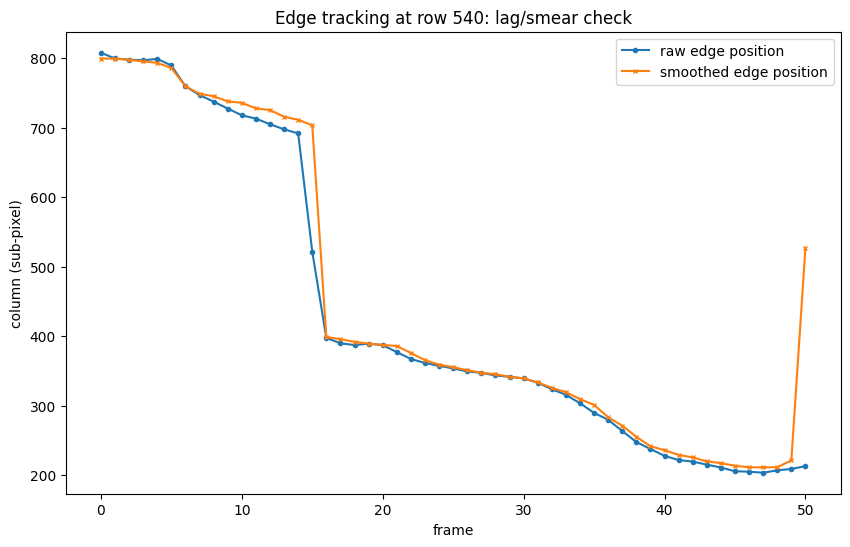

In [50]:
def edge_position(alpha_row, level=0.5):
    '''Sub-pixel column where a 1D alpha profile crosses `level`, via linear interp
    at the first crossing from foreground(1) to backing(0) scanning left->right,
    or None if no crossing.'''
    row = alpha_row.astype(np.float64)
    above = row >= level
    crossings = np.where(np.diff(above.astype(int)) != 0)[0]
    if len(crossings) == 0:
        return None
    i = crossings[0]
    x0, x1 = row[i], row[i + 1]
    frac = (level - x0) / (x1 - x0) if x1 != x0 else 0.0
    return i + frac

MOVING_ROW = frame.shape[0] // 2  # pick a row that actually crosses the moving subject

raw_positions = [edge_position(alphas[t][MOVING_ROW]) for t in range(len(alphas))]
smooth_positions = [edge_position(smoothed_stack[t][MOVING_ROW]) for t in range(smoothed_stack.shape[0])]

plt.plot(raw_positions, label="raw edge position", marker='o', ms=3)
plt.plot(smooth_positions, label="smoothed edge position", marker='x', ms=3)
plt.xlabel("frame"); plt.ylabel("column (sub-pixel)")
plt.legend(); plt.title(f"Edge tracking at row {MOVING_ROW}: lag/smear check")
plt.show()